In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"
from transformers import AutoModelForCausalLM, AutoTokenizer

model_path = "/home/lym/data1/LLM-model/meta-llama/Meta-Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_path)
# model = AutoModelForCausalLM.from_pretrained(
#     model_path,
#     device_map="auto",
#     torch_dtype="auto",
#     attn_implementation="eager",
# )
# model.eval()

In [ ]:
import sys
sys.path.append("/home/lym/LLM-Research/SLASH/src/slash")
import torch
import numpy as np
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from utils import (
    get_token_spans,
    compute_global_span,
    build_local_spans,
    build_sawtooth_mask,
)

# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 16, and the edges are: (0, 9) (0, 3) (0, 5) (1, 6) (1, 4) (1, 9) (2, 4) (2, 7) (3, 13) (3, 4) (3, 14) (3, 11) (3, 8) (4, 12) (4, 8) (4, 14) (4, 6) (5, 6) (5, 13) (5, 8) (5, 10) (5, 9) (6, 11) (6, 15) (6, 8) (7, 14) (7, 15) (9, 13) (9, 16) (10, 16) (10, 15) (10, 13) (11, 13) (12, 15) (13, 15) (14, 16). Is there a cycle in this graph?"
# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 11, and the edges are: (0, 6) (0, 2) (0, 3) (0, 10) (0, 7) (0, 11) (1, 6) (1, 3) (1, 2) (1, 4) (1, 11) (1, 7) (1, 8) (1, 9) (2, 4) (2, 7) (2, 6) (2, 8) (2, 10) (2, 11) (2, 9) (2, 5) (3, 11) (3, 5) (3, 6) (3, 4) (3, 8) (4, 11) (4, 7) (4, 10) (4, 9) (4, 6) (5, 10) (5, 7) (5, 9) (5, 11) (5, 8) (6, 11) (6, 9) (6, 7) (6, 10) (6, 8) (7, 8) (7, 11) (7, 9) (7, 10) (8, 9) (8, 10) (9, 11) (9, 10) (10, 11). Is there a cycle in this graph?"
# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 11, and the edges are: (0, 3) (0, 10) (0, 7) (0, 5) (0, 8) (0, 11) (0, 2) (0, 1) (0, 4) (1, 6) (1, 9) (1, 2) (1, 4) (1, 7) (1, 8) (1, 5) (1, 10) (2, 5) (2, 9) (2, 10) (2, 7) (2, 3) (2, 8) (2, 11) (3, 10) (3, 4) (3, 6) (3, 5) (3, 7) (4, 9) (4, 5) (4, 11) (4, 10) (4, 6) (4, 7) (5, 8) (5, 10) (5, 11) (5, 6) (5, 9) (6, 11) (6, 7) (6, 9) (7, 11) (7, 8) (7, 9) (7, 10) (8, 9) (8, 10) (9, 11) (9, 10) (10, 11). Is there a cycle in this graph?"
# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 14, and the edges are: (0, 9) (0, 4) (0, 8) (0, 10) (0, 7) (0, 1) (0, 13) (0, 14) (0, 6) (0, 2) (0, 3) (0, 5) (0, 12) (1, 4) (1, 9) (1, 14) (1, 3) (1, 2) (1, 12) (1, 8) (1, 11) (1, 6) (1, 13) (1, 7) (1, 5) (1, 10) (2, 9) (2, 12) (2, 14) (2, 4) (2, 11) (2, 7) (2, 5) (2, 6) (2, 8) (2, 13) (2, 10) (3, 8) (3, 5) (3, 12) (3, 6) (3, 11) (3, 9) (3, 10) (3, 13) (3, 7) (3, 4) (3, 14) (4, 7) (4, 10) (4, 9) (4, 8) (4, 12) (4, 6) (4, 13) (4, 14) (4, 11) (5, 8) (5, 12) (5, 7) (5, 10) (5, 14) (5, 9) (5, 11) (5, 6) (5, 13) (6, 8) (6, 9) (6, 13) (6, 10) (6, 12) (6, 7) (6, 14) (6, 11) (7, 12) (7, 9) (7, 8) (7, 11) (7, 10) (7, 14) (7, 13) (8, 13) (8, 10) (8, 9) (8, 11) (8, 14) (8, 12) (9, 10) (9, 13) (9, 11) (10, 11) (10, 12) (10, 13) (10, 14) (11, 13) (11, 12) (11, 14) (12, 13) (12, 14). Is there a cycle in this graph?"

def plot_heatmap(attn_matrix, ideal_mask, sample_idx, layer, head, sink_ratio=None, ideal_ratio=None, other_ratio=None, savepath=None):
    mpl.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "legend.fontsize": 9,
    })

    fig, (ax1, ax2, ax3) = plt.subplots(
        1, 3, figsize=(16, 6), 
        gridspec_kw={'width_ratios': [1.3, 1, 0.2]},
        dpi=300
    )

    vmax = 0.11
    vmin = 0.0
    mask = np.triu(np.ones_like(attn_matrix, dtype=bool))
    sns.heatmap(
        attn_matrix,
        cmap="coolwarm",
        vmin=vmin, vmax=vmax,
        cbar=False,
        cbar_kws={"shrink": 0.7, "pad": 0.02, "format": "%.2f"},
        # xticklabels=40, yticklabels=40,
        xticklabels=False, yticklabels=False,
        ax=ax1,
        square=True,
        # mask=mask
    )
    ax1.set_facecolor('#d3d3d3')
    ax1.set_title(f"Layer {layer} Head {head}", fontsize=16)
    ax1.tick_params(axis='both', which='major', labelsize=11, labelrotation=0)

    sns.heatmap(
        ideal_mask,
        cmap="gray",
        cbar=False,
        ax=ax2,
        xticklabels=False, yticklabels=False,
        square=True
    )
    # ax2.set_title("Ideal sawtooth")
    ax2.axis('off')   # 不绘制坐标轴刻度与框线

    # 比例条（使用累积 bottom，移除未使用的 bottoms 变量）
    if sink_ratio is not None and ideal_ratio is not None and other_ratio is not None:
        ratios = [other_ratio, ideal_ratio, sink_ratio]
        # colors = ["#FED082", "#91C4E1", "#4A7BB6"]
        colors = ["#4A7BB6", "#FED082", "#91C4E1"]
        colors = ["#8A8DC0", "#E7BDC7", "#FECFA1"]
        colors = [
            "#D5D8DC", # 极浅灰 (Pale Grey)        - 呼应黑白图，用于 <10% 的小比例，让它安静地待着
            "#6B8BA4",  # 雾霾蓝 (Muted Slate Blue) - 呼应 coolwarm 的冷端，占大比例
            "#CF7F7A"  # 枯玫瑰 (Muted Salmon)     - 呼应 coolwarm 的暖端，占大比例
        ]


        labels = ['Noise', 'Structured', 'Sink']

        bottom_acc = 0.0
        bar_x = 0
        bar_width = 0.25 
        for r, c in zip(ratios, colors):
            ax3.bar(bar_x, r, bottom=bottom_acc, width=bar_width, color=c, edgecolor='black', linewidth=0.7, align='center')
            ax3.text(
                bar_x, 
                bottom_acc + r / 2, 
                f"{r * 100:.1f}%", 
                ha='center', 
                va='center', 
                fontsize=10, 
                fontweight='bold',
                color='black'
            )
            bottom_acc += r

        ax3.set_ylim(0, 1)
        ax3.set_xlim(-0.25, 0.25)
        ax3.set_xticks([])
        ax3.set_yticks([])
        for name, spine in ax3.spines.items():
            spine.set_visible(name in ['left'])  # 显示左侧和底部边框
        
        # for name, spine in ax3.spines.items():
        #     spine.set_visible(True)  # 确保边框可见
        #     spine.set_linewidth(1.5)  # 设置边框宽度
        #     spine.set_color('black')  # 设置边框颜色为黑色
        
        ax3.spines['left'].set_linewidth(0.6)
        ax3.spines['left'].set_color('black')
        ax3.spines['left'].set_position(('data', -0.125))  # 将左侧刻度线移动到 x=-0.1

        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color, edgecolor='black', label=label) for color, label in reversed(list(zip(colors, labels)))]
        ax3.legend(
            handles=legend_elements, 
            loc='upper left', 
            bbox_to_anchor=(0.8, 1), 
            frameon=False,
            fontsize=12
        )

        ax3.set_facecolor('white')
    else:
        ax3.axis('off')

    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()


def attn_ratio_global(full_attn, roi_start, roi_end, ideal_mask):
    # 只用 ROI 行，所有列
    roi_rows = full_attn[roi_start:roi_end, :]
    total = roi_rows.sum()
    if total == 0:
        return 0.0, 0.0, 0.0

    # 1. 第一列（全局）
    first_col_sum = roi_rows[:, 0].sum()

    # 2. 除第一列外且 ideal_mask==1（全局）
    ideal_sum = roi_rows[:, roi_start:roi_end+1].sum()

    # 3. 其他（全局）
    other_sum = total - first_col_sum - ideal_sum

    return first_col_sum / total, ideal_sum / total, other_sum / total


def plot_roi_and_first_column_zoom(full_attn, g_start, g_end,
                                   cmap="coolwarm", vmax=0.15,
                                   roi_figsize=(5, 5), sink_figsize=(1.4, 9),
                                   cb_fraction=0.035, cb_aspect=20,
                                   save_roi=None, save_sink=None):
    """
    使用 seaborn.heatmap 绘制（行为与 notebook 中 full_attn/roi 一致）：
      - 左：ROI 热力图（sns）
      - 右：full_attn 第一列的放大图（仅第一列，sns）
    返回 (fig_roi, fig_sink, ax_roi, ax_sink)
    """
    # ROI
    roi = full_attn[g_start:g_end+1, g_start:g_end+1]
    fig_roi, ax_roi = plt.subplots(figsize=roi_figsize, dpi=300)
    sns.heatmap(
        roi,
        ax=ax_roi,
        cmap=cmap,
        vmin=0.0, vmax=vmax,
        square=True,
        cbar=True,
        cbar_kws={"fraction": cb_fraction, "pad": 0.02, "aspect": cb_aspect, "shrink": 0.8, "format": "%.2f"},
        xticklabels=40, yticklabels=40,
    )
    ax_roi.tick_params(axis='both', which='major', labelsize=11, labelrotation=0)
    plt.tight_layout()
    if save_roi:
        fig_roi.savefig(save_roi, bbox_inches="tight", dpi=300, transparent=True)

    # First-column zoom (sns heatmap on a single-column 2D array)
    col = full_attn[:, 0:2]  # keep 2D
    fig_sink, ax_sink = plt.subplots(figsize=sink_figsize, dpi=300)
    sns.heatmap(
        col,
        ax=ax_sink,
        cmap=cmap,
        vmin=0.0, vmax=vmax,
        # square=True,
        cbar=False,
        xticklabels=False,
        yticklabels=False,
    )
    ax_sink.tick_params(axis='y', which='major', labelsize=11, labelrotation=0)
    plt.tight_layout()
    if save_sink:
        fig_sink.savefig(save_sink, bbox_inches="tight", dpi=300, transparent=True)

    return fig_roi, fig_sink, ax_roi, ax_sink

data_path = "/home/lym/data1/Datasets/GraphWiz/GraphInstruct-Test/cycle_test.json"
data = []
with open(data_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

sample_list = []
for item in data:
    spans = get_token_spans(item["input_prompt"], tokenizer)
    g_start, g_end, span_len, spans_sorted = compute_global_span(spans)
    sample_dict = {
        "input_prompt": item["input_prompt"],
        "g_start": g_start,
        "g_end": g_end,
        "span_len": span_len,
        "spans_sorted": spans_sorted
    }
    if span_len > 300 and span_len < 350:
        sample_list.append(sample_dict)
print(f"Number of samples with span length between 300 and 350: {len(sample_list)}")

# layer, head = 12, 24
# layer, head = 12, 25
# layer, head = 12, 17
# layer, head = 12, 18
layer = 12
heads = range(0, 32)
heads = [26]

for i, sample in enumerate(sample_list[1:2]):

    min_other_ratio = 1.0
    min_sink_ratio = None
    min_ideal_ratio = None
    min_head = -1
    min_full_attn = None

    print(f"Sample {i}: span length = {sample['span_len']}")
    enc = tokenizer(
        sample["input_prompt"],
        return_tensors="pt",
        truncation=True,
    ).to(model.device)
    with torch.no_grad():
        out = model(enc.input_ids, output_attentions=True, use_cache=False)
    attn_np = np.stack(
        [a[0].to(torch.float32).detach().cpu().numpy() for a in out.attentions],
        axis=0
    ) 

    local_spans = build_local_spans(sample["g_start"], sample["spans_sorted"])
    ideal_mask = build_sawtooth_mask(sample["span_len"], local_spans)

    for head in heads:
        full_attn = attn_np[layer, head]

        roi_attn = full_attn[sample["g_start"]:sample["g_end"] + 1, sample["g_start"]:sample["g_end"] + 1]
        sink_ratio, ideal_ratio, other_ratio = attn_ratio_global(full_attn, sample["g_start"], sample["g_end"], ideal_mask)
        print(f"  Layer {layer} Head {head}: sink: {sink_ratio:.4f}, ideal: {ideal_ratio:.4f}, other: {other_ratio:.4f}")
        plot_heatmap(full_attn, ideal_mask, i, layer, head, sink_ratio, ideal_ratio, other_ratio)
        if other_ratio < min_other_ratio and head not in []:
            min_other_ratio = other_ratio
            min_head = head
            min_full_attn = full_attn
            min_sink_ratio = sink_ratio
            min_ideal_ratio = ideal_ratio
    print(f"  Selected head: {min_head}, sink: {min_sink_ratio:.4f}, ideal: {min_ideal_ratio:.4f}, other: {min_other_ratio:.4f}")
    # plot_heatmap(min_full_attn, ideal_mask, i, layer, min_head, min_sink_ratio, min_ideal_ratio, min_other_ratio)
    fig_roi, fig_sink, _, _ = plot_roi_and_first_column_zoom(
        full_attn, sample['g_start'], sample['g_end'],
        vmax=0.15,
        # save_roi="roi.png",
        # save_sink="first_column_zoom.png"
    )
    del out, attn_np, full_attn, ideal_mask, roi_attn
    torch.cuda.empty_cache()

Number of samples with span length between 300 and 350: 16
Sample 0: span length = 306


NameError: name 'model' is not defined

Number of samples with span length between 300 and 350: 16
Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 11, and the edges are: (0, 6) (0, 2) (0, 3) (0, 10) (0, 7) (0, 11) (1, 6) (1, 3) (1, 2) (1, 4) (1, 11) (1, 7) (1, 8) (1, 9) (2, 4) (2, 7) (2, 6) (2, 8) (2, 10) (2, 11) (2, 9) (2, 5) (3, 11) (3, 5) (3, 6) (3, 4) (3, 8) (4, 11) (4, 7) (4, 10) (4, 9) (4, 6) (5, 10) (5, 7) (5, 9) (5, 11) (5, 8) (6, 11) (6, 9) (6, 7) (6, 10) (6, 8) (7, 8) (7, 11) (7, 9) (7, 10) (8, 9) (8, 10) (9, 11) (9, 10) (10, 11). Is there a cycle in this graph?
[320, 15, 11, 220, 21, 8, 320, 15, 11, 220, 17, 8, 320, 15, 11, 220, 18, 8, 320, 15, 11, 220, 605, 8, 320, 15, 11, 220, 22, 8, 320, 15, 11, 220, 806, 8, 320, 16, 11, 220, 21, 8, 320, 16, 11, 220, 18, 8, 320, 16, 11

/home/lym/anaconda3/envs/graphllm/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


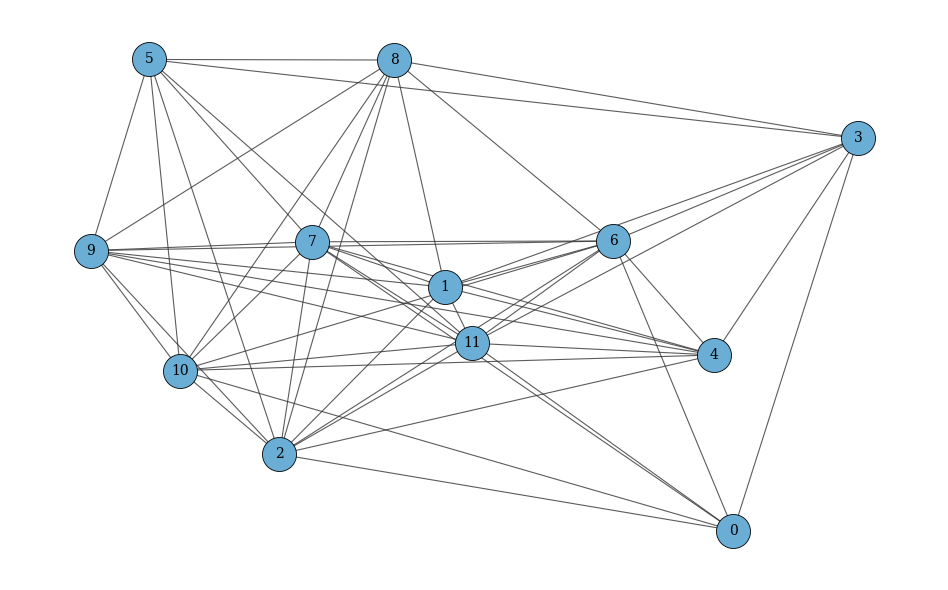

In [8]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import json

def plot_graph_from_prompt(prompt,
                           figsize=(10,6),
                           layout='organic',        # 'auto'|'spring'|'circular'|'kamada_kawai'|'organic'
                           node_size=600,
                           node_color='white',
                           edge_color='0.2',
                           edge_alpha=0.8,
                           color_by_degree=False,
                           show_labels=True,
                           max_labels=40,
                           seed=42,
                           jitter_scale=0.08,    # only for layout='organic'
                           iterations=350,       # spring_layout iterations for 'organic'
                           dpi=100,
                           savepath=None):

    edges = re.findall(r'\((\d+)\s*,\s*(\d+)\)', prompt)
    if not edges:
        raise ValueError("no edges found in prompt")
    edges = {(min(int(u), int(v)), max(int(u), int(v))) for u, v in edges}
    edges = list(edges)  # 转回列表
    # edges = [(int(u), int(v)) for u, v in edges]
    G = nx.Graph()
    G.add_edges_from(edges)
    nodes = sorted(G.nodes())
    N = len(nodes)
    E = G.number_of_edges()

    density = 2 * E / (N * (N - 1)) if N > 1 else 0.0
    if layout == 'auto':
        if N > 30 or density > 0.45:
            layout = 'circular'
        elif N <= 12:
            layout = 'spring'
        else:
            layout = 'kamada_kawai'

    rng = np.random.RandomState(seed)

    if layout == 'spring' or layout == 'organic':
        pos = nx.spring_layout(G, seed=seed, iterations=iterations)
        if layout == 'organic' and N > 1:
            coords = np.vstack([pos[n] for n in nodes])
            diffs = coords[None, :, :] - coords[:, None, :]
            dists = np.sqrt((diffs ** 2).sum(-1))
            np.fill_diagonal(dists, np.nan)
            nn = np.nanmean(np.nanmin(dists, axis=1))
            jitter = rng.normal(scale=max(1e-3, jitter_scale * (nn if np.isfinite(nn) else 1.0)), size=coords.shape)
            coords = coords + jitter
            coords[:, 0] *= 1.5
            pos = {n: coords[i] for i, n in enumerate(nodes)}
        if 1 in pos:
            pos[1] = np.array([0, 0])
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    else:
        pos = nx.circular_layout(G)

    plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.gca()
    ax.set_facecolor('white')

    if color_by_degree:
        degrees = np.array([G.degree(n) for n in nodes], dtype=float)
        cmap = plt.get_cmap('Blues')
        nc = (degrees - degrees.min()) / max(1e-9, degrees.max() - degrees.min())
        node_colors = cmap(0.3 + 0.7 * nc)
    else:
        cmap = plt.get_cmap('Blues')
        node_colors = cmap(0.5)

    nx.draw_networkx_edges(G, pos,
                           alpha=edge_alpha,
                           edge_color=edge_color,
                           width=0.8,
                           ax=ax)
    nx.draw_networkx_nodes(G, pos,
                           node_size=node_size,
                           node_color=node_colors,
                           edgecolors='black',
                           linewidths=0.6,
                           ax=ax)

    if show_labels and N <= max_labels:
        labels = {n: str(n) for n in nodes}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_family='serif', ax=ax)

    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, bbox_inches='tight', transparent=True)  # 推荐 .svg/.pdf
    plt.show()

def plot_adj_from_prompt(prompt, figsize=(4,4), cmap="Greys", savepath=None, max_ticks=20):
    edges = re.findall(r'\((\d+)\s*,\s*(\d+)\)', prompt)
    if not edges:
        raise ValueError("no edges found in prompt")
    edges = [(int(u), int(v)) for u, v in edges]
    print(edges)
    nodes = sorted({n for e in edges for n in e})
    idx = {n:i for i,n in enumerate(nodes)}
    N = len(nodes)

    A = np.zeros((N, N), dtype=int)
    for u, v in edges:
        i, j = idx[u], idx[v]
        if i == j:
            A[i, j] = 1
        else:
            A[i, j] = 1
            A[j, i] = 1

    from matplotlib.colors import ListedColormap
    cmap_bw = ListedColormap(['white', 'black'])  # 0 -> white, 1 -> black

    plt.figure(figsize=figsize, dpi=300)
    ax = sns.heatmap(
        A,
        cmap=cmap_bw,
        cbar=False,
        square=True,
        linewidths=0.6,
        linecolor="0.92",
        vmax=1.0,
        vmin=0.0,
        rasterized=False,
        xticklabels=False,
        yticklabels=False
    )

    # 刻度：自动稀疏以防拥挤；左侧刻度水平显示（非竖直）
    if N <= max_ticks:
        xt_pos = np.arange(N)
        yt_pos = np.arange(N)
        xt_labels = yt_labels = nodes
    else:
        step = int(np.ceil(N / max_ticks))
        xt_pos = np.arange(0, N, step)
        yt_pos = np.arange(0, N, step)
        xt_labels = [nodes[i] for i in xt_pos]
        yt_labels = [nodes[i] for i in yt_pos]

    ax.set_xticks(xt_pos + 0.5)   # heatmap cell-centered tick alignment
    ax.set_yticks(yt_pos + 0.5)
    # 把 x 轴刻度移动到上方并水平显示
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xticklabels(xt_labels, rotation=0, ha='center', fontsize=11)
    ax.set_yticklabels(yt_labels, rotation=0, va='center', fontsize=11)

    ax.set_xlabel("Node ID")
    ax.set_ylabel("Node ID")
    ax.set_aspect('equal')
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, bbox_inches="tight", transparent=True)  # 推荐 .pdf 或 .svg
    plt.show()

def _find_subsequence(seq, subseq):
    if not subseq:
        return []
    L, l = len(seq), len(subseq)
    return [i for i in range(L - l + 1) if seq[i:i + l] == subseq]

def build_attention_adjacency(roi_attn, enc, g_start, g_end, tokenizer, prompt=None, agg='max'):
    """
    从 roi_attn 构建 node-level 注意力邻接矩阵。
    """
    if prompt is None:
        raise ValueError("prompt is required")
    edges = re.findall(r'\((\d+)\s*,\s*(\d+)\)', prompt)
    if not edges:
        raise ValueError("no edges found in prompt")
    nodes = sorted({int(u) for e in edges for u in e})

    enc_roi = enc.input_ids[0, g_start:g_end+1].tolist()

    node_to_token_idxs = {}
    for n in nodes:
        tok_seq = tokenizer.encode(str(n), add_special_tokens=False)
        starts = _find_subsequence(enc_roi, tok_seq)
        if starts:
            idxs = []
            for s in starts:
                idxs.extend(range(s, s + len(tok_seq)))
            node_to_token_idxs[n] = sorted(set(idxs))
        else:
            matches = []
            for i, tid in enumerate(enc_roi):
                try:
                    s = tokenizer.decode([tid]).strip()
                except Exception:
                    s = ""
                if s == str(n):
                    matches.append(i)
            node_to_token_idxs[n] = matches

    N = len(nodes)
    A = np.full((N, N), np.nan, dtype=float)

    for i_u, u in enumerate(nodes):
        idxs_u = node_to_token_idxs.get(u, [])
        for i_v, v in enumerate(nodes):
            idxs_v = node_to_token_idxs.get(v, [])
            if not idxs_u or not idxs_v:
                A[i_u, i_v] = np.nan
                continue

            vals = []
            for r in idxs_u:
                for c in idxs_v:
                    if c < r:                     # <- 关键约束（不能等于）
                        vals.append(float(roi_attn[r, c]))
            if len(vals) == 0:
                A[i_u, i_v] = np.nan
                continue

            if agg == 'max':
                A[i_u, i_v] = float(np.max(vals))
                A[i_v, i_u] = float(np.max(vals))
            elif agg == 'mean':
                A[i_u, i_v] = float(np.mean(vals))
                A[i_v, i_u] = float(np.mean(vals))
            elif agg == 'sum':
                A[i_u, i_v] = float(np.sum(vals))
                A[i_v, i_u] = float(np.sum(vals))
            else:
                raise ValueError("agg must be one of: 'max','mean','sum'")
            if i_u == i_v:
                A[i_u, i_v] = 0.0

    return nodes, A


def plot_attention_adjacency(nodes, attn_adj, figsize=(4,4), cmap="Greys",
                             vmax=None, savepath=None, max_ticks=20):
    N = len(nodes)
    plt.figure(figsize=figsize, dpi=300)
    mask = np.isnan(attn_adj)

    ax = sns.heatmap(
        np.nan_to_num(attn_adj, nan=0.0),
        mask=mask,
        cmap=cmap,
        cbar=True,
        square=True,
        linewidths=0.6,
        linecolor="0.92",
        vmax=vmax,
        vmin=0.0,
        rasterized=False,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"fraction": 0.035, "pad": 0.02, "aspect": 20, "shrink": 0.8, "format": "%.2f"}
    )

    if mask.any():
        for (i, j), m in np.ndenumerate(mask):
            if m:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color="#ffffff", lw=0))
    # 刻度稀疏化 & 水平左侧刻度
    if N <= max_ticks:
        pos = np.arange(N)
        labels = nodes
    else:
        step = int(np.ceil(N / max_ticks))
        pos = np.arange(0, N, step)
        labels = [nodes[i] for i in pos]

    ax.set_xticks(pos + 0.5)
    ax.set_yticks(pos + 0.5)
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=11)
    ax.set_yticklabels(labels, rotation=0, va='center', fontsize=11)

    ax.set_xlabel("Node ID")
    ax.set_ylabel("Node ID")
    ax.set_aspect('equal')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches="tight", transparent=True)
    plt.show()


data_path = "/home/lym/data1/Datasets/GraphWiz/GraphInstruct-Test/cycle_test.json"
data = []
with open(data_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

sample_list = []
for item in data:
    spans = get_token_spans(item["input_prompt"], tokenizer)
    g_start, g_end, span_len, spans_sorted = compute_global_span(spans)
    sample_dict = {
        "input_prompt": item["input_prompt"],
        "g_start": g_start,
        "g_end": g_end,
        "span_len": span_len,
        "spans_sorted": spans_sorted
    }
    if span_len > 300 and span_len < 350:
        sample_list.append(sample_dict)
print(f"Number of samples with span length between 300 and 350: {len(sample_list)}")

sample = sample_list[1]
print(sample['input_prompt'])
sample_tokens_id = tokenizer(sample['input_prompt'])['input_ids']
print(sample_tokens_id[sample['g_start']:sample['g_end']+1])
sample_tokens = tokenizer.convert_ids_to_tokens(sample_tokens_id)
print(sample_tokens[sample['g_start']:sample['g_end']+1])

# plot_adj_from_prompt(sample['input_prompt'], figsize=(5,5), cmap="Greys_r")

# plot_graph_from_prompt(sample['input_prompt'], seed=115)
plot_graph_from_prompt(
    sample['input_prompt'],
    figsize=(10,6),
    layout='organic',        # 'auto'|'spring'|'circular'|'kamada_kawai'|'organic'
    node_size=600,
    node_color='white',
    edge_color='0.2',
    edge_alpha=0.8,
    color_by_degree=False,
    show_labels=True,
    max_labels=40,
    seed=42,
    jitter_scale=0.08,    # only for layout='organic'
    iterations=350,       # spring_layout iterations for 'organic'
    dpi=100,
    savepath=None
)
# layer, head = 12, 26
# enc = tokenizer(
#     sample["input_prompt"],
#     return_tensors="pt",
#     truncation=True,
# ).to(model.device)
# with torch.no_grad():
#     out = model(enc.input_ids, output_attentions=True, use_cache=False)
# attn_np = np.stack(
#     [a[0].to(torch.float32).detach().cpu().numpy() for a in out.attentions],
#     axis=0
# )
# full_attn = attn_np[layer, head]
# roi_attn = full_attn[sample["g_start"]:sample["g_end"] + 1, sample["g_start"]:sample["g_end"] + 1]

# # 使用示例（在该 notebook 中已有变量）
# nodes, attn_adj = build_attention_adjacency(roi_attn, enc, sample['g_start'], sample['g_end'], tokenizer, prompt=sample['input_prompt'], agg='max')
# plot_attention_adjacency(nodes, attn_adj, figsize=(5,5), cmap="Greys", vmax=0.28)

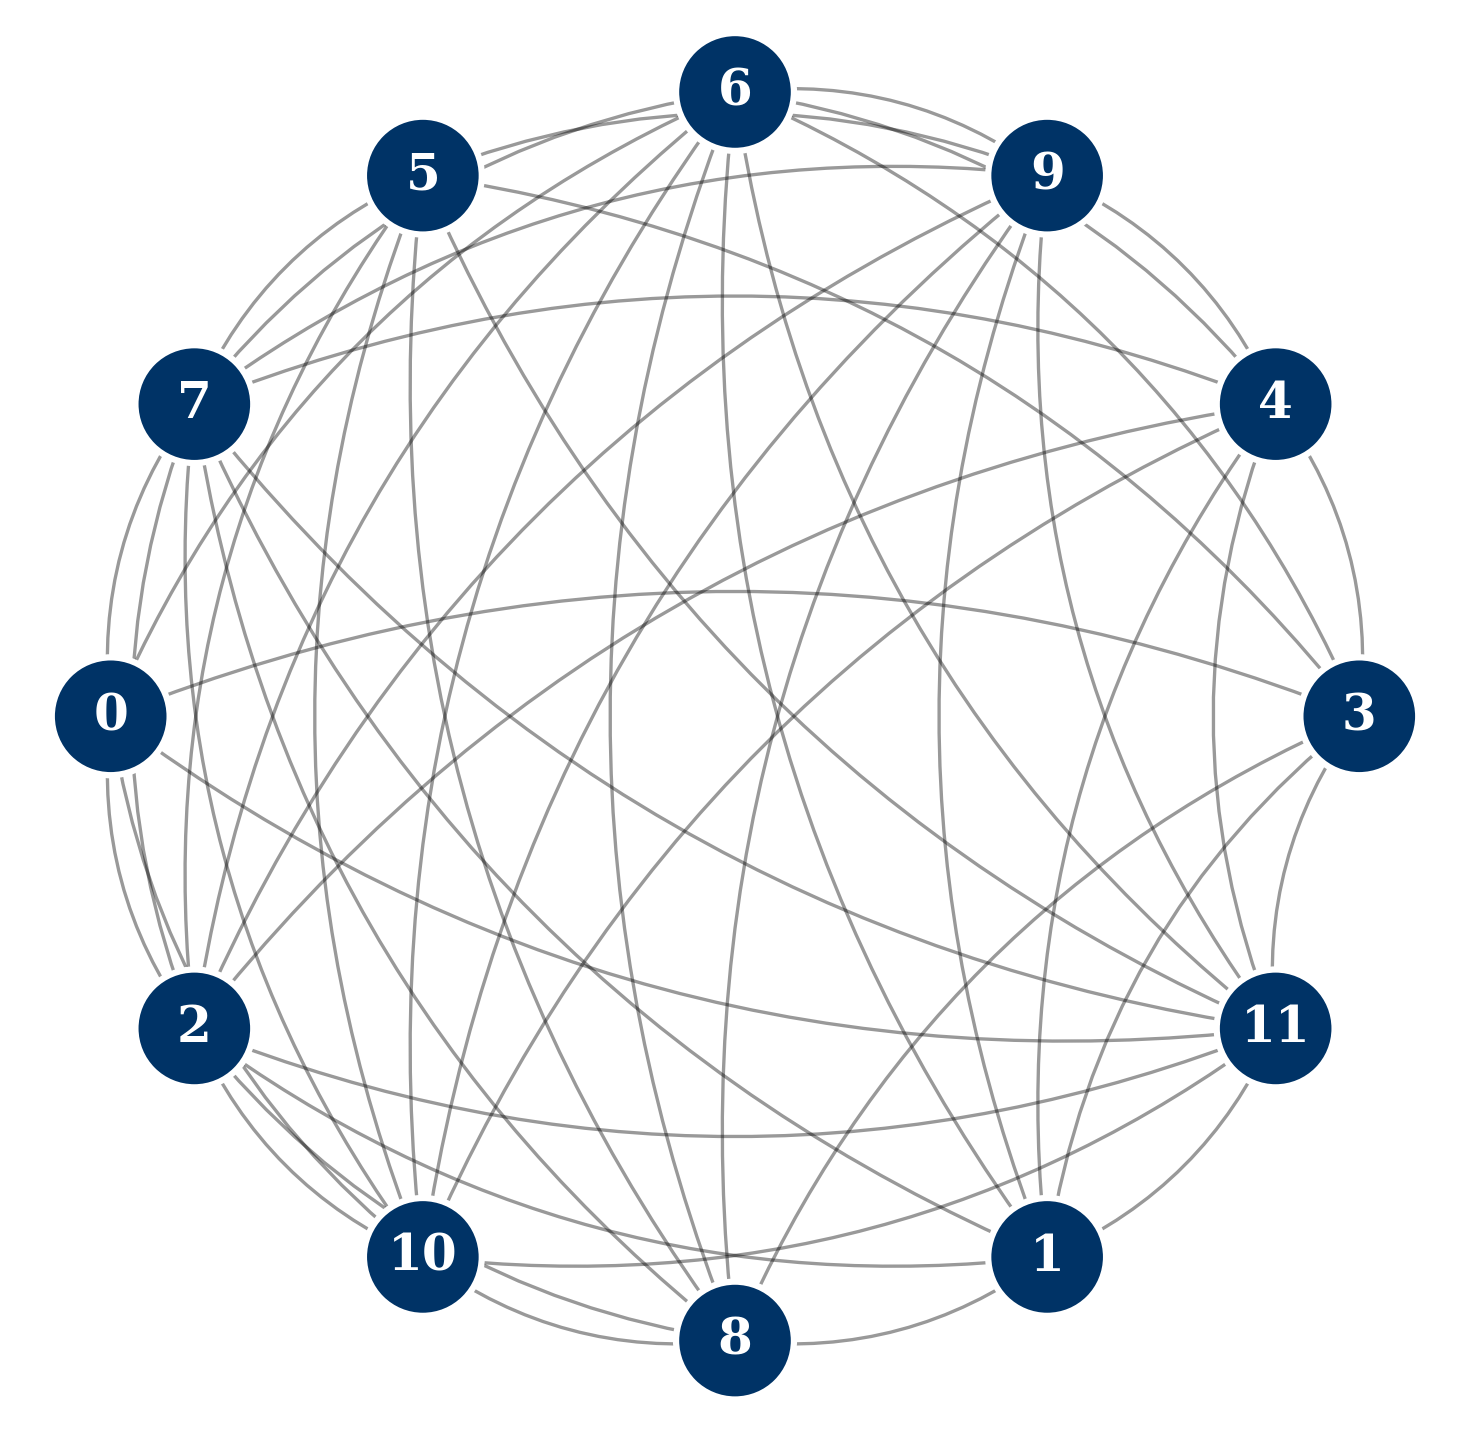

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import re

def plot_graph_optimized(prompt,
                         figsize=(5, 8),  # 修改：窄高比例 (宽5, 高8)
                         node_size=800,
                         base_color='#003366', # 修改：深蓝色 (Midnight Blue)
                         edge_alpha=0.4,       # 修改：降低透明度以适应稠密边
                         dpi=300,             # 修改：论文发表级分辨率
                         savepath=None):
    
    # 1. 解析数据 (保持原有逻辑)
    edges_str = re.findall(r'\((\d+)\s*,\s*(\d+)\)', prompt)
    if not edges_str:
        print("Warning: No edges found. Generating a sample dense graph for demo.")
        # 演示用：生成一个 12 节点的随机稠密图
        G = nx.erdos_renyi_graph(12, 0.7, seed=42)
    else:
        edges = {(min(int(u), int(v)), max(int(u), int(v))) for u, v in edges_str}
        G = nx.Graph()
        G.add_edges_from(edges)

    nodes = sorted(G.nodes())
    N = len(nodes)
    
    # 2. 布局优化：强制使用圆形布局 (Circular Layout)
    # 对于 12 个节点的稠密图，圆形是展示连接关系最清晰的方式
    pos = nx.circular_layout(G)
    
    # 3. 创建画布
    plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.gca()
    ax.set_facecolor('white')
    
    # 4. 绘制边 (核心优化：使用曲线)
    # 稠密图中，直线会糊成一团。我们使用 matplotlib 的 FancyArrowPatch 来画曲线。
    
    # 获取配色方案
    cmap = plt.get_cmap('Blues')
    
    for (u, v) in G.edges():
        # 计算弧度：根据距离远近调整弧度，避免所有线重合
        # 这里简单使用固定的 rad，也可以根据 u,v 在圆周上的距离动态计算
        # rad > 0 曲线向外弯，rad < 0 向内。
        # 对于 circular layout，统一的 rad=0.2 效果通常类似弦图
        
        # 这种画法需要手动添加 patch
        n1 = pos[u]
        n2 = pos[v]
        
        # 使用贝塞尔曲线 (Arc)
        # rad 决定弯曲程度。
        edge_patch = patches.FancyArrowPatch(
            n1, n2,
            arrowstyle='-',
            connectionstyle='arc3,rad=0.2', # 关键：设置曲线弧度
            color='black', # 边的颜色，可以是灰色或淡蓝
            alpha=edge_alpha,
            linewidth=0.8,
            zorder=1 # 放在节点下方
        )
        ax.add_patch(edge_patch)

    # 5. 绘制节点 (优化配色)
    # 计算度数用于可能的颜色映射（可选），或者统一使用深蓝色
    degrees = dict(G.degree())
    node_colors = [base_color for n in nodes] # 统一深蓝色，显得专业
    
    # 如果想根据度数深浅变化（可选）：
    # max_deg = max(degrees.values())
    # node_colors = [cmap(0.5 + 0.5 * (degrees[n] / max_deg)) for n in nodes]

    nx.draw_networkx_nodes(G, pos,
                           node_size=node_size,
                           node_color=node_colors,
                           edgecolors='white', # 节点边缘白色，增加对比
                           linewidths=1.5,
                           ax=ax,
    )

    # 6. 绘制标签
    # 字体设为白色，位于节点内部，或者设为黑色位于节点外部
    labels = {n: str(n) for n in nodes}
    nx.draw_networkx_labels(G, pos, 
                            labels=labels, 
                            font_size=12, 
                            font_color='white', # 深色节点配白色文字
                            font_family='serif', # 衬线体更适合论文
                            font_weight='bold',
                            ax=ax,
                            )

    # 7. 调整显示区域
    # 因为画布是窄高的，但圆是正圆，需要去掉多余空白并保持比例
    ax.set_aspect('equal')
    ax.axis('off')
    
    # 可以在底部添加标题或其他说明，利用窄高布局的下半部分
    # plt.title("Graph Structure", y=-0.1, fontsize=14, fontfamily='serif')

    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, bbox_inches='tight', transparent=True, dpi=dpi)
    
    plt.show()


plot_graph_optimized(sample['input_prompt'])


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
['#003366', '#FF8C00', '#003366', '#003366', '#003366', '#003366', '#003366', '#003366', '#003366', '#003366', '#003366', '#003366']


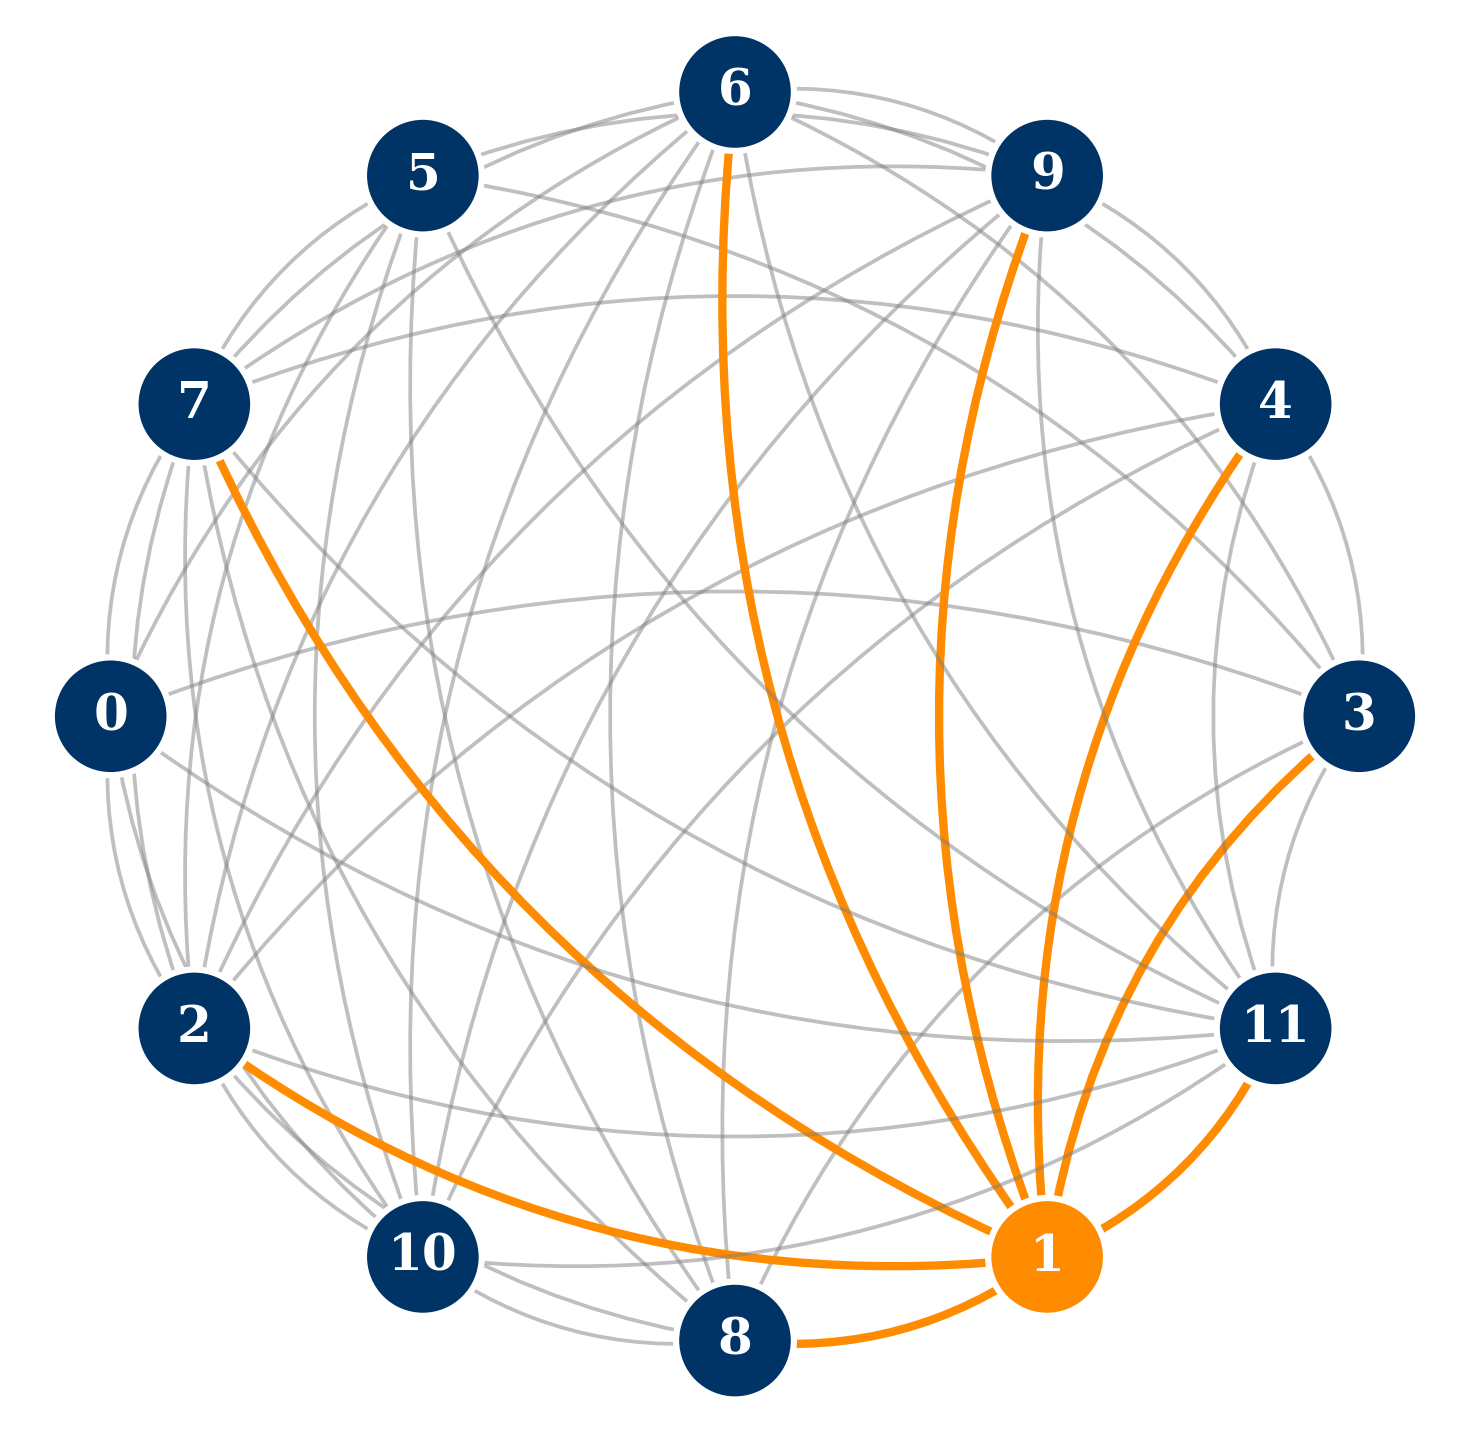

In [26]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re

def plot_graph_highlighted(prompt,
                           figsize=(5, 8),   # 保持窄高比例
                           node_size=800,
                           base_node_color='#003366', # 普通节点：深蓝
                           highlight_color='#FF8C00', # 高亮颜色：深橙色 (DarkOrange)
                           base_edge_alpha=0.5,       # 普通边：更淡一点，凸显高亮边
                           dpi=300,
                           savepath=None):
    
    # 1. 解析数据
    edges_str = re.findall(r'\((\d+)\s*,\s*(\d+)\)', prompt)
    
    if not edges_str:
        # 演示模式：如果未提供数据，生成一个包含 Node 1 的随机图
        print("Warning: No edges found in prompt. Generating demo graph.")
        G = nx.erdos_renyi_graph(12, 0.5, seed=42)
        # 确保 1 存在且有一些连接
        if 1 not in G.nodes():
            G.add_node(1)
            G.add_edge(1, 2)
            G.add_edge(1, 5)
    else:
        edges = {(min(int(u), int(v)), max(int(u), int(v))) for u, v in edges_str}
        G = nx.Graph()
        G.add_edges_from(edges)

    nodes = sorted(G.nodes())
    
    # 2. 布局：使用 Circular Layout 保持清晰
    pos = nx.circular_layout(G)
    
    # 3. 创建画布
    plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.gca()
    ax.set_facecolor('white')
    
    # Target Node ID
    target_id = 1

    # 4. 绘制边 (区分普通边和高亮边)
    # 我们希望高亮边画在普通边上面，所以可以分两轮画，或者利用 zorder
    
    for (u, v) in G.edges():
        # 判断是否连接了目标节点
        is_highlight = (u == target_id or v == target_id)
        
        if is_highlight:
            # 高亮边样式
            edge_c = highlight_color
            edge_a = 1.0   # 完全不透明
            edge_w = 2.0   # 稍微加粗
            edge_z = 10    # 图层在最上
        else:
            # 普通边样式 (背景)
            edge_c = 'gray' 
            edge_a = base_edge_alpha
            edge_w = 0.9
            edge_z = 1     # 图层在下

        # 绘制曲线
        n1 = pos[u]
        n2 = pos[v]
        
        edge_patch = patches.FancyArrowPatch(
            n1, n2,
            arrowstyle='-',
            connectionstyle='arc3,rad=0.2', 
            color=edge_c,
            alpha=edge_a,
            linewidth=edge_w,
            # zorder=edge_z # 关键：让橙色线盖住灰色线
        )
        ax.add_patch(edge_patch)

    # 5. 绘制节点 (颜色列表推导)
    node_colors = []
    for n in nodes:
        if n == target_id:
            node_colors.append(highlight_color) # 橙色
        else:
            node_colors.append(base_node_color) # 深蓝
    print(nodes)
    print(node_colors)
    # 绘制节点
    # 注意：zorder 要比所有的线都高 (比如 20)
    nx.draw_networkx_nodes(G, pos,
                           nodelist=nodes,
                           node_size=node_size,
                           node_color=node_colors,
                           edgecolors='white',
                           linewidths=1.5,
                           ax=ax,
)

    # 6. 绘制标签
    labels = {n: str(n) for n in nodes}
    nx.draw_networkx_labels(G, pos, 
                            labels=labels, 
                            font_size=12, 
                            font_color='white', 
                            font_family='serif', 
                            font_weight='bold',
                            ax=ax,)

    # 7. 收尾调整
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, bbox_inches='tight', transparent=True, dpi=dpi)
        print(f"Graph saved to {savepath}")
    
    plt.show()


plot_graph_highlighted(sample['input_prompt'])


Otsu Threshold: 1.5742094848641133


/tmp/ipykernel_4027986/1372089324.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='lower right', fontsize=10)
/tmp/ipykernel_4027986/1372089324.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


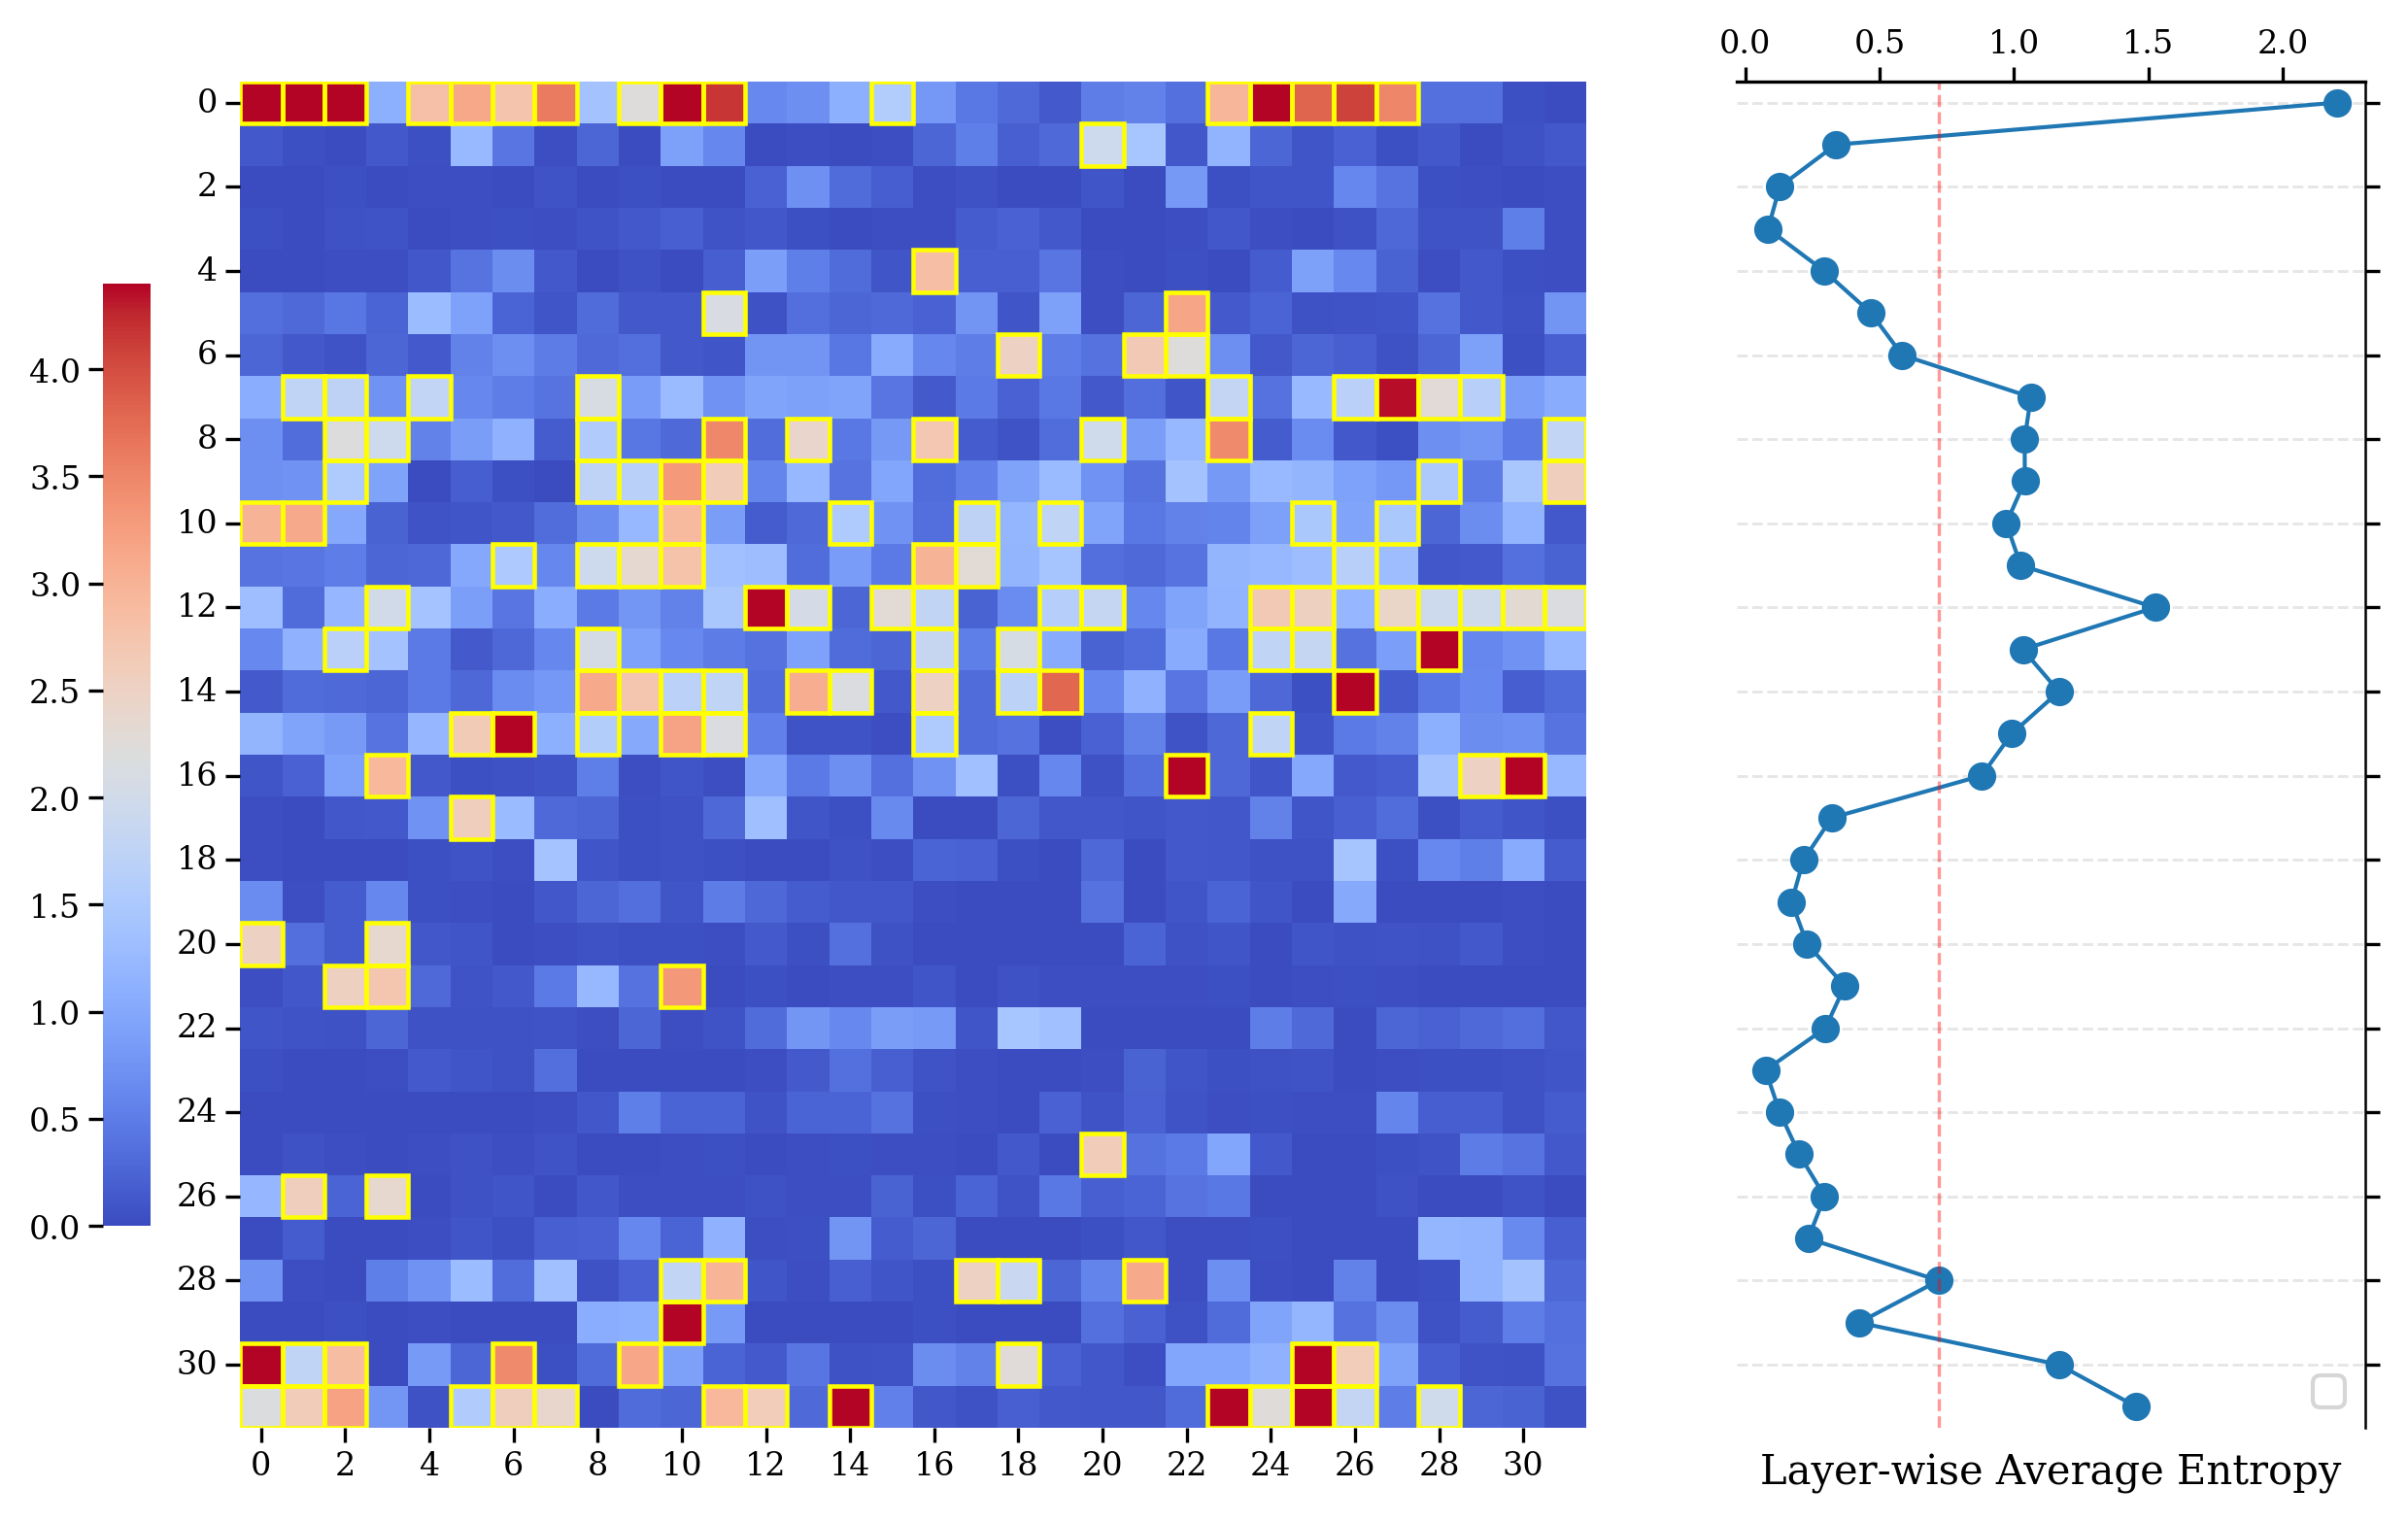

In [32]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.filters import threshold_otsu

# 加载数据
entropy_data_path = "/home/lym/LLM-Research/SLASH/outputs/final_select/select1.0/GraphWiz_cycle/Meta-Llama-3.1-8B-Instruct/entropy_results/cycle_entropy_per_head/cycle_entropy_per_head.npz"
entropy_data = np.load(entropy_data_path)
avg = entropy_data["avg_entropy"]

# 计算 Otsu 阈值
otsu_threshold = threshold_otsu(avg)
print(f"Otsu Threshold: {otsu_threshold}")

# 计算每行的平均值
row_means = avg.mean(axis=1)

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
})
# 绘图
n = avg.shape[0]
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6), gridspec_kw={'width_ratios': [1, 0.4]}, dpi=200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6), gridspec_kw={'width_ratios': [1, 0.35], 'wspace': 0.05}, dpi=300)

# 热力图
sns.heatmap(
    avg, 
    ax=ax1, 
    cmap="coolwarm", 
    square=True, 
    cbar=True,
    vmin=0.0, vmax=4.4,
    cbar_kws={"shrink": 0.7, "pad": 0.05, "format": "%.1f", "location": "left"},
    xticklabels=2, yticklabels=2,
)
ax1.tick_params(axis='both', labelrotation=0, labelsize=8, pad=2) 
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(labelsize=8, pad=2)
# 在热力图中框出高于 Otsu 阈值的区域
for i in range(avg.shape[0]):
    for j in range(avg.shape[1]):
        if avg[i, j] >= otsu_threshold-0.1:
            ax1.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='yellow', lw=1.1))

# 折线图
ax2.plot(row_means, np.arange(n), marker='o', linewidth=1)
ax2.set_ylim(-0.5, n - 0.5)
ax2.invert_yaxis()  # layer 0 在顶部
ax2.xaxis.set_ticks_position('top')
ax2.xaxis.tick_top()
yt_ticks = np.arange(0, n, 2)  # 每隔2层设置一个刻度
ax2.set_yticks(yt_ticks)
ax2.set_yticklabels([])  # 移除左侧刻度
ax2.yaxis.tick_right()  # 将 y 轴刻度移到右侧
ax2.yaxis.set_label_position("right")  # 将 y 轴标签移到右侧
ax2.tick_params(axis='x', labelsize=8, pad=2)
# 计算 row_means 的 Otsu 阈值并绘制直线
row_means_threshold = threshold_otsu(row_means)
ax2.axvline(row_means_threshold, color='red', linestyle='--', linewidth=0.8, alpha=0.4)

# 修改标题
ax2.set_xlabel("Layer-wise Average Entropy", labelpad=6, fontsize=10)
ax2.legend(loc='lower right', fontsize=10)

# 添加网格线
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, which='major', linestyle='--', color='0.9', linewidth=0.7)

# 隐藏左侧和底部边框
for s in ['left', 'bottom']:
    ax2.spines[s].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_linewidth(0.6)
ax2.spines['right'].set_color('black')
ax2.spines['top'].set_visible(True)

# ax2.set_ylabel("Layer")

plt.tight_layout()
plt.show()